# Bot #5 Backtest (MES)
Direct notebook implementation (no imports from local strategy .py files).

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    PROJECT_ROOT = ROOT.parent
elif (ROOT / "notebooks").exists():
    PROJECT_ROOT = ROOT
else:
    PROJECT_ROOT = ROOT

req_file = PROJECT_ROOT / "requirements.txt"

required = ["numpy", "pandas", "matplotlib", "databento", "dotenv", "pyarrow"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    print(f"Installing missing packages: {missing}")
    if req_file.exists():
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_file)])
    else:
        pip_names = ["python-dotenv" if p == "dotenv" else p for p in missing]
        subprocess.check_call([sys.executable, "-m", "pip", "install", *pip_names])
    print("Dependency install complete. If imports still fail, restart the kernel and run all cells again.")
else:
    print("All required packages are already installed in this kernel.")

All required packages are already installed in this kernel.


In [2]:
import os
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import databento as db
from dotenv import load_dotenv

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    PROJECT_ROOT = ROOT.parent
elif (ROOT / "notebooks").exists():
    PROJECT_ROOT = ROOT
else:
    PROJECT_ROOT = ROOT

load_dotenv(PROJECT_ROOT / ".env")
DATABENTO_API_KEY = os.getenv("DATABENTO_API_KEY")
if not DATABENTO_API_KEY:
    print("DATABENTO_API_KEY not set. Local DBN mode will be used; API fallback is disabled by default.")

DATA_DIR = PROJECT_ROOT / "data" / "cache"
OUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
BOT5 = {
    "start_hour": 0, "start_minute": 0,
    "end_hour": 8, "end_minute": 0,
    "supertrend_factor": 10.0,
    "atr_period": 100,
    "pivot_left": 1000,
    "pivot_right": 3,
    "rsi_length": 14,
    "ema_slow": 200,
    "ema_distance": 6.0,
    "divergence_lookback_left": 0,
    "divergence_lookback_right": 20,
    "rsi_max_longs": 100,
    "rsi_min_shorts": 0,
    "proximity_threshold": 1.5,
}

In [4]:
LOCAL_DBN_PATH = PROJECT_ROOT / "mesdata" / "glbx-mdp3-20230306-20260304.ohlcv-1m.dbn.zst"


def _normalize_end(end: str) -> str:
    if str(end).lower() in {"today", "now"}:
        return datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M")
    return str(end)


def _normalize_databento_frame(df: pd.DataFrame, preferred_prefixes=("MES", "ES")) -> pd.DataFrame:
    if isinstance(df.index, pd.MultiIndex):
        if "ts_event" in df.index.names:
            df = df.reset_index()
        else:
            df = df.reset_index()

    if "ts_event" not in df.columns and isinstance(df.index, pd.DatetimeIndex):
        idx_name = df.index.name if df.index.name else "ts_event"
        df = df.reset_index().rename(columns={idx_name: "ts_event"})

    if "ts_event" not in df.columns:
        raise ValueError("Databento dataframe missing ts_event column")

    df = df.rename(columns={c: c.lower() for c in df.columns})

    need = ["open", "high", "low", "close", "volume"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if "symbol" in df.columns:
        raw_rows = len(df)
        sym = df["symbol"].astype(str)

        # Drop calendar/inter-commodity spreads; keep outright symbols only.
        outrights = df[~sym.str.contains("-", regex=False)].copy()
        if len(outrights) == 0:
            outrights = df.copy()

        chosen_prefix = None
        for pref in preferred_prefixes:
            m = outrights["symbol"].astype(str).str.startswith(pref)
            if m.any():
                outrights = outrights[m].copy()
                chosen_prefix = pref
                break

        # Convert ts first, then choose one contract per minute by highest volume.
        outrights["ts_event"] = pd.to_datetime(outrights["ts_event"], utc=True)
        if outrights["ts_event"].duplicated().any():
            outrights = outrights.sort_values(["ts_event", "volume", "symbol"])
            outrights = outrights.groupby("ts_event", as_index=False).tail(1)

        df = outrights
        print(
            f"Local DBN symbol normalization: rows {raw_rows:,} -> {len(df):,}; "
            f"prefix={chosen_prefix or 'unfiltered'}"
        )

    df["ts_event"] = pd.to_datetime(df["ts_event"], utc=True)
    df = df.set_index("ts_event").sort_index()

    px_cols = ["open", "high", "low", "close"]
    if df[px_cols].abs().max().max() > 1_000_000:
        df[px_cols] = df[px_cols] / 1e9

    out = df[need].copy()
    out.index = out.index.tz_convert("US/Eastern")
    return out


def _to_eastern_ts(value: str):
    ts = pd.Timestamp(value)
    if ts.tz is None:
        return ts.tz_localize("US/Eastern")
    return ts.tz_convert("US/Eastern")


def fetch_mes_data(
    start="2023-06-01T00:00",
    end="today",
    force_refresh=False,
    cache_name="mes_1m_ohlcv_local.parquet",
    local_dbn_path=None,
    prefer_local=True,
    allow_api_fallback=False,
):
    cache_path = DATA_DIR / cache_name
    if cache_path.exists() and not force_refresh:
        df = pd.read_parquet(cache_path)
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("Cached dataframe missing DatetimeIndex")
        if df.index.tz is None:
            df.index = df.index.tz_localize("US/Eastern")
        print(f"Loaded {len(df):,} bars from cache: {cache_path}")
        return df.sort_index()

    local_path = Path(local_dbn_path) if local_dbn_path else LOCAL_DBN_PATH
    if prefer_local and local_path.exists():
        print(f"Loading local DBN file: {local_path}")
        store = db.DBNStore.from_file(str(local_path))
        raw_df = store.to_df()
        df = _normalize_databento_frame(raw_df)

        start_ts = _to_eastern_ts(start)
        end_ts = _to_eastern_ts(end) if str(end).lower() not in {"today", "now"} else pd.Timestamp.now(tz="US/Eastern")
        df = df.loc[(df.index >= start_ts) & (df.index < end_ts)].copy()

        df.to_parquet(cache_path)
        print(f"Loaded {len(df):,} bars from local DBN and cached to: {cache_path}")
        return df

    if not allow_api_fallback:
        raise FileNotFoundError(
            f"Local DBN file not found at {local_path}. Set local_dbn_path or put file at LOCAL_DBN_PATH."
        )

    if not DATABENTO_API_KEY:
        raise EnvironmentError("DATABENTO_API_KEY is required for API fallback mode")

    client = db.Historical(key=DATABENTO_API_KEY)
    raw = client.timeseries.get_range(
        dataset="GLBX.MDP3",
        symbols=["MES.c.0"],
        schema="ohlcv-1m",
        start=start,
        end=_normalize_end(end),
        stype_in="continuous",
    )
    df = _normalize_databento_frame(raw.to_df())
    df.to_parquet(cache_path)
    print(f"Loaded {len(df):,} bars from Databento API and cached to: {cache_path}")
    return df

In [5]:
def rma(series: pd.Series, period: int) -> pd.Series:
    arr = series.astype(float).to_numpy()
    out = np.full(len(arr), np.nan)
    if period <= 0:
        raise ValueError("period must be > 0")
    if len(arr) < period:
        return pd.Series(out, index=series.index)

    out[period - 1] = np.nanmean(arr[:period])
    for i in range(period, len(arr)):
        out[i] = ((out[i - 1] * (period - 1)) + arr[i]) / period
    return pd.Series(out, index=series.index)


def true_range(df: pd.DataFrame) -> pd.Series:
    high = df["high"].astype(float)
    low = df["low"].astype(float)
    prev_close = df["close"].astype(float).shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    if len(tr):
        tr.iloc[0] = high.iloc[0] - low.iloc[0]
    return tr


def atr(df: pd.DataFrame, period: int) -> pd.Series:
    return rma(true_range(df), period)


def supertrend(df: pd.DataFrame, atr_period: int, factor: float) -> pd.DataFrame:
    high = df["high"].to_numpy(dtype=float)
    low = df["low"].to_numpy(dtype=float)
    close = df["close"].to_numpy(dtype=float)
    idx = df.index

    atr_vals = atr(df, atr_period).to_numpy()
    hl2 = (high + low) / 2.0
    upper = hl2 + factor * atr_vals
    lower = hl2 - factor * atr_vals

    n = len(df)
    final_upper = np.full(n, np.nan)
    final_lower = np.full(n, np.nan)
    direction = np.full(n, np.nan)
    direction_change = np.zeros(n, dtype=int)
    st = np.full(n, np.nan)

    valid = np.where(~np.isnan(atr_vals))[0]
    if len(valid) == 0:
        return pd.DataFrame({
            "supertrend": st,
            "direction": direction,
            "direction_change": direction_change,
            "upper_band": final_upper,
            "lower_band": final_lower,
        }, index=idx)

    start = int(valid[0])
    final_upper[start] = upper[start]
    final_lower[start] = lower[start]
    direction[start] = 1.0
    st[start] = final_lower[start]

    for i in range(start + 1, n):
        prev_upper = final_upper[i - 1]
        prev_lower = final_lower[i - 1]
        prev_close = close[i - 1]

        curr_upper = upper[i]
        curr_lower = lower[i]

        if np.isnan(curr_upper) or np.isnan(curr_lower):
            final_upper[i] = prev_upper
            final_lower[i] = prev_lower
            direction[i] = direction[i - 1]
            st[i] = st[i - 1]
            continue

        final_upper[i] = curr_upper if (curr_upper < prev_upper or prev_close > prev_upper) else prev_upper
        final_lower[i] = curr_lower if (curr_lower > prev_lower or prev_close < prev_lower) else prev_lower

        prev_dir = direction[i - 1]
        if close[i] > prev_upper:
            curr_dir = 1.0
        elif close[i] < prev_lower:
            curr_dir = -1.0
        else:
            curr_dir = prev_dir

        direction[i] = curr_dir
        if prev_dir == 1.0 and curr_dir == -1.0:
            direction_change[i] = 1
        elif prev_dir == -1.0 and curr_dir == 1.0:
            direction_change[i] = -1

        st[i] = final_lower[i] if curr_dir == 1.0 else final_upper[i]

    return pd.DataFrame({
        "supertrend": st,
        "direction": direction,
        "direction_change": direction_change,
        "upper_band": final_upper,
        "lower_band": final_lower,
    }, index=idx)


def ema(series: pd.Series, period: int) -> pd.Series:
    return series.astype(float).ewm(span=period, adjust=False).mean()


def wick_proximity(df: pd.DataFrame, lookback: int = 5, threshold: float = 0.25):
    high = df["high"].astype(float)
    low = df["low"].astype(float)
    long_checks = [(high - high.shift(i)).abs() <= threshold for i in range(1, lookback + 1)]
    short_checks = [(low - low.shift(i)).abs() <= threshold for i in range(1, lookback + 1)]
    long_prox = pd.concat(long_checks, axis=1).fillna(False).any(axis=1)
    short_prox = pd.concat(short_checks, axis=1).fillna(False).any(axis=1)
    return long_prox, short_prox


def wick_close_check(df: pd.DataFrame, lookback: int = 3):
    close = df["close"].astype(float)
    high = df["high"].astype(float)
    low = df["low"].astype(float)
    long_checks = [close > high.shift(i) for i in range(1, lookback + 1)]
    short_checks = [close < low.shift(i) for i in range(1, lookback + 1)]
    long_ok = pd.concat(long_checks, axis=1).fillna(False).all(axis=1)
    short_ok = pd.concat(short_checks, axis=1).fillna(False).all(axis=1)
    return long_ok, short_ok


def minute_of_day(index: pd.DatetimeIndex):
    return (index.hour * 60 + index.minute).astype(int)

def rsi(series: pd.Series, length: int = 14) -> pd.Series:
    delta = series.astype(float).diff().fillna(0.0)
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)

    avg_gain = rma(gain, length)
    avg_loss = rma(loss, length)

    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    out = 100.0 - (100.0 / (1.0 + rs))
    out = out.where(avg_loss != 0, 100.0)
    out = out.where(avg_gain != 0, 0.0)
    out = out.mask((avg_gain == 0) & (avg_loss == 0), 50.0)
    return out


def pivot_high(series: pd.Series, left: int, right: int) -> pd.Series:
    s = series.astype(float)
    if left < 0 or right < 0:
        raise ValueError("left and right must be >= 0")

    candidate = s.shift(right)
    if left == 0:
        window = right + 1
        roll_max = s.rolling(window=window, min_periods=window).max()
        return candidate.where(candidate.eq(roll_max))

    window = left + right + 1
    roll_max = s.rolling(window=window, min_periods=window).max()
    return candidate.where(candidate.eq(roll_max))


def pivot_low(series: pd.Series, left: int, right: int) -> pd.Series:
    s = series.astype(float)
    if left < 0 or right < 0:
        raise ValueError("left and right must be >= 0")

    candidate = s.shift(right)
    if left == 0:
        window = right + 1
        roll_min = s.rolling(window=window, min_periods=window).min()
        return candidate.where(candidate.eq(roll_min))

    window = left + right + 1
    roll_min = s.rolling(window=window, min_periods=window).min()
    return candidate.where(candidate.eq(roll_min))


def detect_divergence(
    rsi_values: pd.Series,
    high: pd.Series,
    low: pd.Series,
    lookback_left: int = 0,
    lookback_right: int = 20,
    shunt: int = 1,
    use_ob_os: bool = False,
    ob_level: int = 70,
    os_level: int = 30,
    rsi_max_longs: int = 100,
    rsi_min_shorts: int = 0,
):
    p_high_raw = pivot_high(rsi_values, lookback_left, lookback_right)
    p_low_raw = pivot_low(rsi_values, lookback_left, lookback_right)

    # Pine: pvthi = pvthi_raw[shunt], pvtlo = pvtlo_raw[shunt]
    p_high = p_high_raw.shift(shunt)
    p_low = p_low_raw.shift(shunt)
    ph_cond = p_high.notna()
    pl_cond = p_low.notna()

    # Pine div_Func uses source[2], then ta.valuewhen(...)[2].
    rsi_2 = rsi_values.astype(float).shift(2)
    high_2 = high.astype(float).shift(2)
    low_2 = low.astype(float).shift(2)

    def _valuewhen_last(condition: pd.Series, source: pd.Series) -> pd.Series:
        return source.where(condition).ffill()

    pre_rp_h = _valuewhen_last(ph_cond, rsi_2).shift(2)
    pre_cp_h = _valuewhen_last(ph_cond, high_2).shift(2)
    pre_rp_l = _valuewhen_last(pl_cond, rsi_2).shift(2)
    pre_cp_l = _valuewhen_last(pl_cond, low_2).shift(2)

    bear = ph_cond & high_2.gt(pre_cp_h) & rsi_2.lt(pre_rp_h)
    bull = pl_cond & low_2.lt(pre_cp_l) & rsi_2.gt(pre_rp_l)
    bear_hidden = ph_cond & high_2.lt(pre_cp_h) & rsi_2.gt(pre_rp_h)
    bull_hidden = pl_cond & low_2.gt(pre_cp_l) & rsi_2.lt(pre_rp_l)

    if use_ob_os:
        bear &= rsi_2 >= ob_level
        bear_hidden &= rsi_2 >= ob_level
        bull &= rsi_2 <= os_level
        bull_hidden &= rsi_2 <= os_level

    bear &= rsi_2 >= rsi_min_shorts
    bear_hidden &= rsi_2 >= rsi_min_shorts
    bull &= rsi_2 <= rsi_max_longs
    bull_hidden &= rsi_2 <= rsi_max_longs

    return pd.DataFrame({
        "bull_div": bull.fillna(False),
        "bear_div": bear.fillna(False),
        "bull_div_hidden": bull_hidden.fillna(False),
        "bear_div_hidden": bear_hidden.fillna(False),
        "rsi_pivot_high": ph_cond,
        "rsi_pivot_low": pl_cond,
    }, index=rsi_values.index)

In [6]:
def generate_signals_bot5(
    df: pd.DataFrame,
    ema_distance: float = 6.0,
    start_time: int = 0,
    end_time: int = 480,
    proximity_threshold: float = 1.5,
    rsi_max_longs: float = 100.0,
    rsi_min_shorts: float = 0.0,
):
    mins = minute_of_day(df.index)
    time_ok = (mins >= start_time) & (mins <= end_time)

    high = df["high"].to_numpy(dtype=float)
    low = df["low"].to_numpy(dtype=float)
    close = df["close"].to_numpy(dtype=float)
    ema200 = df["ema200"].to_numpy(dtype=float)
    rsi_vals = df["rsi"].to_numpy(dtype=float)
    bull_div = df["bull_div"].fillna(False).to_numpy(dtype=bool)
    bear_div = df["bear_div"].fillna(False).to_numpy(dtype=bool)
    direction = df["direction_b5"].to_numpy(dtype=float)
    upper_band = df["upper_band_b5"].to_numpy(dtype=float)
    lower_band = df["lower_band_b5"].to_numpy(dtype=float)
    # Pine equivalent: Tsl2 = Trend == 1 ? TDown : TUp
    # Here TDown is the upper band, TUp is the lower band.
    tsl2 = np.where(direction == 1.0, upper_band, lower_band)

    n = len(df)
    signal = np.zeros(n, dtype=int)
    exit_signal = np.zeros(n, dtype=bool)
    position = np.zeros(n, dtype=int)
    exit_reason = np.full(n, "", dtype=object)

    pos = 0
    entry_price = np.nan
    long_prox_triggered = False
    short_prox_triggered = False

    for i in range(n):
        if pos == 0:
            long_prox_triggered = False
            short_prox_triggered = False

            long_entry = (
                bull_div[i]
                and rsi_vals[i] <= rsi_max_longs
                and high[i] <= ema200[i] - ema_distance
                and time_ok[i]
            )
            short_entry = (
                bear_div[i]
                and rsi_vals[i] >= rsi_min_shorts
                and low[i] >= ema200[i] + ema_distance
                and time_ok[i]
            )

            if long_entry:
                pos = 1
                signal[i] = 1
                entry_price = close[i]
            elif short_entry:
                pos = -1
                signal[i] = -1
                entry_price = close[i]

        elif pos == 1:
            reason = None
            if (not long_prox_triggered) and (high[i] >= ema200[i] - proximity_threshold):
                long_prox_triggered = True
            if long_prox_triggered and low[i] <= entry_price:
                reason = "proximity_return"
            if reason is None and high[i] >= ema200[i] and low[i] <= ema200[i]:
                reason = "ema200_touch"
            if reason is None and close[i] < tsl2[i]:
                reason = "supertrend_stop"
            if reason is None and mins[i] > end_time:
                reason = "eod_close"

            if reason is not None:
                exit_signal[i] = True
                exit_reason[i] = reason
                pos = 0
                entry_price = np.nan
                long_prox_triggered = False

        elif pos == -1:
            reason = None
            if (not short_prox_triggered) and (low[i] <= ema200[i] + proximity_threshold):
                short_prox_triggered = True
            if short_prox_triggered and high[i] >= entry_price:
                reason = "proximity_return"
            if reason is None and high[i] >= ema200[i] and low[i] <= ema200[i]:
                reason = "ema200_touch"
            if reason is None and close[i] > tsl2[i]:
                reason = "supertrend_stop"
            if reason is None and mins[i] > end_time:
                reason = "eod_close"

            if reason is not None:
                exit_signal[i] = True
                exit_reason[i] = reason
                pos = 0
                entry_price = np.nan
                short_prox_triggered = False

        position[i] = pos

    return pd.DataFrame({
        "signal": signal,
        "exit_signal": exit_signal,
        "position": position,
        "exit_reason": exit_reason,
        "tsl2": tsl2,
        "session_ok": time_ok,
    }, index=df.index)

In [7]:
def run_backtest(
    df: pd.DataFrame,
    initial_capital: float = 25_000.0,
    contracts_per_trade: int = 1,
    point_value: float = 5.0,
    commission_rt: float = 2.50,
    slippage_ticks: int = 1,
    tick_size: float = 0.25,
):
    required = {"close", "signal", "exit_signal", "exit_reason"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    prices = df["close"].to_numpy(dtype=float)
    signal = df["signal"].fillna(0).to_numpy(dtype=int)
    exit_signal = df["exit_signal"].fillna(False).to_numpy(dtype=bool)
    exit_reason = df["exit_reason"].fillna("").to_numpy(dtype=object)
    idx = df.index

    slip = slippage_ticks * tick_size
    n = len(df)

    realized = np.zeros(n)
    unrealized = np.zeros(n)
    equity = np.zeros(n)
    position = np.zeros(n, dtype=int)

    trades = []
    pos = 0
    entry_price = 0.0
    entry_time = None
    entry_idx = 0
    cum_realized = 0.0

    for i in range(n):
        px = prices[i]

        if pos == 0 and signal[i] != 0:
            pos = int(signal[i])
            entry_price = px + slip if pos == 1 else px - slip
            entry_time = idx[i]
            entry_idx = i

        elif pos != 0 and exit_signal[i]:
            exit_px = px - slip if pos == 1 else px + slip
            gross_points = (exit_px - entry_price) * pos
            gross_pnl = gross_points * point_value * contracts_per_trade
            net_pnl = gross_pnl - (commission_rt * contracts_per_trade)
            cum_realized += net_pnl

            trades.append({
                "entry_time": entry_time,
                "exit_time": idx[i],
                "direction": pos,
                "entry_price": entry_price,
                "exit_price": exit_px,
                "gross_points": gross_points,
                "gross_pnl_dollars": gross_pnl,
                "net_pnl_dollars": net_pnl,
                "hold_bars": i - entry_idx,
                "exit_reason": str(exit_reason[i]),
            })

            pos = 0
            entry_price = 0.0
            entry_time = None
            entry_idx = 0

        position[i] = pos
        if pos != 0:
            unrealized[i] = (px - entry_price) * pos * point_value * contracts_per_trade
        realized[i] = cum_realized
        equity[i] = initial_capital + realized[i] + unrealized[i]

    if pos != 0 and n:
        i = n - 1
        px = prices[i]
        exit_px = px - slip if pos == 1 else px + slip
        gross_points = (exit_px - entry_price) * pos
        gross_pnl = gross_points * point_value * contracts_per_trade
        net_pnl = gross_pnl - (commission_rt * contracts_per_trade)
        cum_realized += net_pnl

        trades.append({
            "entry_time": entry_time,
            "exit_time": idx[i],
            "direction": pos,
            "entry_price": entry_price,
            "exit_price": exit_px,
            "gross_points": gross_points,
            "gross_pnl_dollars": gross_pnl,
            "net_pnl_dollars": net_pnl,
            "hold_bars": i - entry_idx,
            "exit_reason": "end_of_data",
        })

        realized[i] = cum_realized
        unrealized[i] = 0.0
        equity[i] = initial_capital + cum_realized
        position[i] = 0

    equity_curve = pd.DataFrame({
        "equity": equity,
        "realized_pnl": realized,
        "unrealized_pnl": unrealized,
        "position": position,
    }, index=idx)
    equity_curve["drawdown_dollars"] = equity_curve["equity"].cummax() - equity_curve["equity"]

    trades_df = pd.DataFrame(trades)

    total_pnl = float(equity_curve["equity"].iloc[-1] - initial_capital) if len(equity_curve) else 0.0
    total_return = total_pnl / initial_capital if initial_capital else 0.0
    daily = equity_curve["equity"].resample("1D").last().pct_change(fill_method=None).dropna()
    sharpe = float((daily.mean() / daily.std(ddof=0)) * np.sqrt(252)) if len(daily) > 1 and daily.std(ddof=0) > 0 else 0.0

    if len(trades_df):
        wins = trades_df[trades_df["net_pnl_dollars"] > 0]
        losses = trades_df[trades_df["net_pnl_dollars"] <= 0]
        hit_rate = float(len(wins) / len(trades_df))
        avg_win = float(wins["net_pnl_dollars"].mean()) if len(wins) else 0.0
        avg_loss = float(losses["net_pnl_dollars"].mean()) if len(losses) else 0.0
        gross_win = float(wins["net_pnl_dollars"].sum()) if len(wins) else 0.0
        gross_loss = float(abs(losses["net_pnl_dollars"].sum())) if len(losses) else 0.0
        pf = (gross_win / gross_loss) if gross_loss > 0 else np.inf
        avg_hold = float(trades_df["hold_bars"].mean())
        long_trades = int((trades_df["direction"] == 1).sum())
        short_trades = int((trades_df["direction"] == -1).sum())
    else:
        hit_rate = avg_win = avg_loss = pf = avg_hold = 0.0
        long_trades = short_trades = 0

    metrics = {
        "total_return": total_return,
        "total_pnl_dollars": total_pnl,
        "sharpe": sharpe,
        "max_drawdown": float((equity_curve["drawdown_dollars"] / equity_curve["equity"].cummax().replace(0, np.nan)).max()),
        "max_drawdown_dollars": float(equity_curve["drawdown_dollars"].max()),
        "hit_rate": hit_rate,
        "avg_win_dollars": avg_win,
        "avg_loss_dollars": avg_loss,
        "profit_factor": float(pf),
        "avg_hold_bars": avg_hold,
        "total_trades": int(len(trades_df)),
        "long_trades": long_trades,
        "short_trades": short_trades,
    }

    return {"metrics": metrics, "equity_curve": equity_curve, "trades": trades_df}

In [8]:
prices = fetch_mes_data(
    start="2023-06-01T00:00",
    end="2026-03-07T00:00",
    force_refresh=True,
    cache_name="mes_1m_ohlcv_local_full.parquet",
)
print(f"Loaded {len(prices):,} bars from {prices.index.min()} to {prices.index.max()}")

bot5_df = prices.copy()
bot5_df["ema200"] = ema(bot5_df["close"], BOT5["ema_slow"])
hlc3 = (bot5_df["high"] + bot5_df["low"] + bot5_df["close"]) / 3.0
bot5_df["rsi"] = rsi(hlc3, BOT5["rsi_length"])

st2 = supertrend(bot5_df, atr_period=BOT5["atr_period"], factor=BOT5["supertrend_factor"])
bot5_df["supertrend_b5"] = st2["supertrend"]
bot5_df["direction_b5"] = st2["direction"]
bot5_df["upper_band_b5"] = st2["upper_band"]
bot5_df["lower_band_b5"] = st2["lower_band"]

swing_high_raw = pivot_high(bot5_df["high"], BOT5["pivot_left"], BOT5["pivot_right"])
swing_low_raw = pivot_low(bot5_df["low"], BOT5["pivot_left"], BOT5["pivot_right"])

bot5_df["pvthi"] = swing_high_raw.shift(1)
bot5_df["pvtlo"] = swing_low_raw.shift(1)
bot5_df["swing_high"] = bot5_df["pvthi"].ffill()
bot5_df["swing_low"] = bot5_df["pvtlo"].ffill()

pivot_low_event = swing_low_raw.notna()
low_at_pivot = bot5_df["low"].shift(BOT5["pivot_right"]).where(pivot_low_event)
bot5_df["stop_level"] = low_at_pivot.ffill()

div = detect_divergence(
    rsi_values=bot5_df["rsi"],
    high=bot5_df["high"],
    low=bot5_df["low"],
    lookback_left=BOT5["divergence_lookback_left"],
    lookback_right=BOT5["divergence_lookback_right"],
    shunt=1,
    use_ob_os=False,
    rsi_max_longs=BOT5["rsi_max_longs"],
    rsi_min_shorts=BOT5["rsi_min_shorts"],
)
bot5_df = bot5_df.join(div)

bot5_signals = generate_signals_bot5(
    bot5_df,
    ema_distance=BOT5["ema_distance"],
    start_time=BOT5["start_hour"] * 60 + BOT5["start_minute"],
    end_time=BOT5["end_hour"] * 60 + BOT5["end_minute"],
    proximity_threshold=BOT5["proximity_threshold"],
    rsi_max_longs=BOT5["rsi_max_longs"],
    rsi_min_shorts=BOT5["rsi_min_shorts"],
)

bot5_bt = run_backtest(
    prices[["close"]].join(bot5_signals[["signal", "exit_signal", "exit_reason"]]),
    commission_rt=2.50,
    slippage_ticks=1,
    tick_size=0.25,
)
bot5_bt["metrics"]

Loading local DBN file: /Users/user/Documents/GitHub/tradingalgoNotebook/mesdata/glbx-mdp3-20230306-20260304.ohlcv-1m.dbn.zst
Local DBN symbol normalization: rows 1,693,075 -> 1,060,659; prefix=ES
Loaded 974,171 bars from local DBN and cached to: /Users/user/Documents/GitHub/tradingalgoNotebook/data/cache/mes_1m_ohlcv_local_full.parquet
Loaded 974,171 bars from 2023-06-01 00:00:00-04:00 to 2026-03-04 18:59:00-05:00


{'total_return': 0.15165,
 'total_pnl_dollars': 3791.25,
 'sharpe': 1.5350776307485163,
 'max_drawdown': 0.03652760065585717,
 'max_drawdown_dollars': 1002.5,
 'hit_rate': 0.4212962962962963,
 'avg_win_dollars': 52.293956043956044,
 'avg_loss_dollars': -22.905,
 'profit_factor': 1.662082514734774,
 'avg_hold_bars': 42.636574074074076,
 'total_trades': 432,
 'long_trades': 200,
 'short_trades': 232}

,count,mean,sum
exit_reason,,,
ema200_touch,126,43.263889,5451.25
eod_close,37,-4.898649,-181.25
proximity_return,107,-5.151869,-551.25
supertrend_stop,162,-5.725309,-927.50


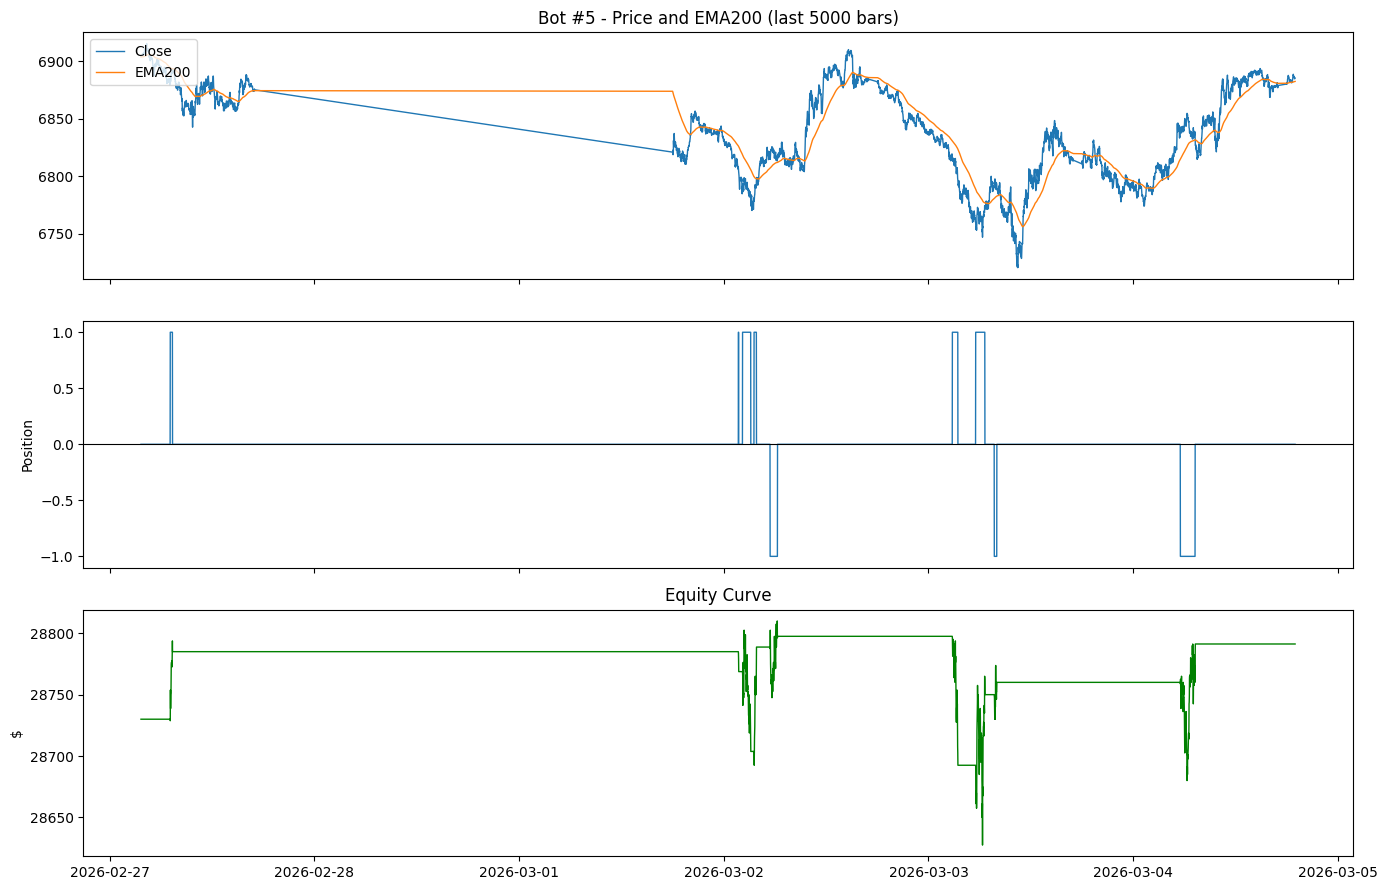

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
plot_df = bot5_df.tail(5000)
plot_eq = bot5_bt["equity_curve"].loc[plot_df.index]

axes[0].plot(plot_df.index, plot_df["close"], label="Close", linewidth=1)
axes[0].plot(plot_df.index, plot_df["ema200"], label="EMA200", linewidth=1)
axes[0].legend(loc="upper left")
axes[0].set_title("Bot #5 - Price and EMA200 (last 5000 bars)")

axes[1].plot(plot_eq.index, plot_eq["position"], label="Position", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Position")

axes[2].plot(plot_eq.index, plot_eq["equity"], label="Equity", color="green", linewidth=1)
axes[2].set_ylabel("$")
axes[2].set_title("Equity Curve")

plt.tight_layout()

trades5 = bot5_bt["trades"].copy()
trades5.groupby("exit_reason")["net_pnl_dollars"].agg(["count", "mean", "sum"]).sort_values("sum", ascending=False)

In [10]:
bot5_bt["trades"].to_csv(OUT_DIR / "bot5_trades_notebook.csv", index=False)
bot5_bt["equity_curve"].to_parquet(OUT_DIR / "bot5_equity_notebook.parquet")
print("Saved:", OUT_DIR / "bot5_trades_notebook.csv")
print("Saved:", OUT_DIR / "bot5_equity_notebook.parquet")

Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_trades_notebook.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_equity_notebook.parquet


## Research-Rigor Extension (Bot #5)

### Economic Hypothesis
Overnight index futures can exhibit transient mispricings because liquidity is thinner, dealer inventory constraints are tighter, and hedging/roll flows are more episodic outside regular cash hours. In that environment, short-lived dislocations are more likely to mean-revert than to persist as stable trends.

Bot #5 operationalizes this as: (1) divergence to detect local momentum exhaustion, and (2) distance-from-EMA to require a measurable dislocation before entry. The signal is intended to capture micro-liquidity reversion, not market beta.

Expected failure mode: when overnight participation becomes one-way (macro shock clusters, sustained directional gamma hedging, elevated volatility regimes), divergence fades can be repeatedly run over. That is why regime diagnostics and filtering are included below.

In [11]:
# RIGOR 1: Base return series for statistical diagnostics

def annualized_sharpe(daily_returns: pd.Series) -> float:
    r = daily_returns.dropna()
    if len(r) < 2:
        return 0.0
    sd = r.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return 0.0
    return float((r.mean() / sd) * np.sqrt(252))


equity_daily = bot5_bt["equity_curve"]["equity"].resample("1D").last().dropna()
strategy_daily_ret = equity_daily.pct_change(fill_method=None).dropna()

benchmark_daily_close = prices["close"].resample("1D").last().dropna()
benchmark_daily_ret = benchmark_daily_close.pct_change(fill_method=None).dropna()

analysis_df = pd.concat(
    [strategy_daily_ret.rename("strategy"), benchmark_daily_ret.rename("benchmark")],
    axis=1,
).dropna()

print(f"Daily observations: {len(analysis_df):,}")
print(f"Strategy Sharpe (annualized): {annualized_sharpe(analysis_df['strategy']):.3f}")
analysis_df.tail()

Daily observations: 859
Strategy Sharpe (annualized): 1.399


,strategy,benchmark
ts_event,,
2026-02-27 00:00:00-05:00,0.001914,-0.003479
2026-03-01 00:00:00-05:00,0.000000,-0.006509
2026-03-02 00:00:00-05:00,0.000434,0.001025
2026-03-03 00:00:00-05:00,-0.001302,-0.006654
2026-03-04 00:00:00-05:00,0.001087,0.013766


Observed Sharpe: 1.3994
Permutation p-value (one-sided): 0.0036


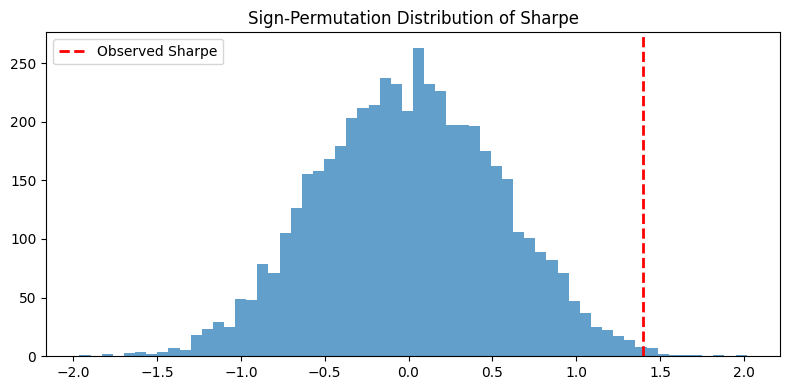

In [12]:
# RIGOR 2: Permutation test on Sharpe (sign-randomization null)
# Null: no directional edge; returns are equally likely to have either sign.

rng = np.random.default_rng(42)
n_perm = 5000
obs_sharpe = annualized_sharpe(analysis_df["strategy"])
vals = analysis_df["strategy"].to_numpy()

perm_sharpes = np.empty(n_perm, dtype=float)
for i in range(n_perm):
    signs = rng.choice(np.array([-1.0, 1.0]), size=len(vals), replace=True)
    perm_vals = vals * signs
    perm_sharpes[i] = annualized_sharpe(pd.Series(perm_vals))

# One-sided p-value for Sharpe >= observed
p_value = float((np.sum(perm_sharpes >= obs_sharpe) + 1) / (n_perm + 1))

print(f"Observed Sharpe: {obs_sharpe:.4f}")
print(f"Permutation p-value (one-sided): {p_value:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(perm_sharpes, bins=60, alpha=0.7)
plt.axvline(obs_sharpe, color="red", linestyle="--", linewidth=2, label="Observed Sharpe")
plt.title("Sign-Permutation Distribution of Sharpe")
plt.legend()
plt.tight_layout()

In [13]:
# RIGOR 3: Alpha/Beta decomposition vs buy-and-hold benchmark

x = analysis_df["benchmark"].to_numpy()
y = analysis_df["strategy"].to_numpy()

x_var = np.var(x)
beta = float(np.cov(y, x, ddof=0)[0, 1] / x_var) if x_var > 0 else 0.0
alpha_daily = float(np.mean(y) - beta * np.mean(x))
alpha_ann = alpha_daily * 252

y_hat = alpha_daily + beta * x
resid = y - y_hat
y_var = np.var(y)
r2 = float(1 - (np.var(resid) / y_var)) if y_var > 0 else 0.0

alpha_beta = pd.Series(
    {
        "beta_to_benchmark": beta,
        "alpha_daily": alpha_daily,
        "alpha_annualized": alpha_ann,
        "r_squared": r2,
    }
)
alpha_beta

beta_to_benchmark    0.015226
alpha_daily          0.000157
alpha_annualized     0.039541
r_squared            0.005362
dtype: float64

Sharpe heatmap table


proximity_threshold,1.0,1.5,2.0
ema_distance,,,
5.0,1.316883,1.332544,1.255163
6.0,1.529558,1.535078,1.442958
7.0,1.681699,1.685271,1.603078


Total return heatmap table


proximity_threshold,1.0,1.5,2.0
ema_distance,,,
5.0,0.13250,0.13415,0.12550
6.0,0.15095,0.15165,0.14165
7.0,0.16465,0.16490,0.15590


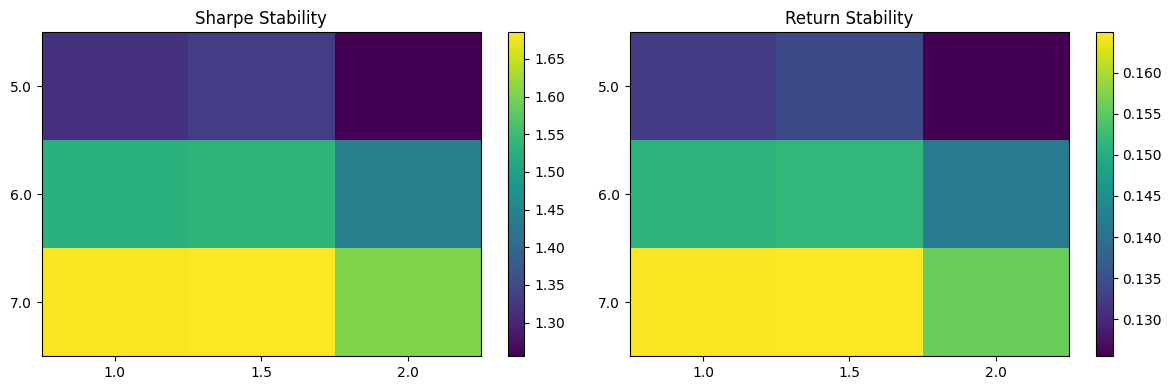

In [14]:
# RIGOR 4: Parameter stability (local grid around baseline)

ema_grid = [5.0, 6.0, 7.0]
prox_grid = [1.0, 1.5, 2.0]

stability_rows = []
for ema_d in ema_grid:
    for prox_t in prox_grid:
        sig = generate_signals_bot5(
            bot5_df,
            ema_distance=ema_d,
            start_time=BOT5["start_hour"] * 60 + BOT5["start_minute"],
            end_time=BOT5["end_hour"] * 60 + BOT5["end_minute"],
            proximity_threshold=prox_t,
            rsi_max_longs=BOT5["rsi_max_longs"],
            rsi_min_shorts=BOT5["rsi_min_shorts"],
        )
        bt = run_backtest(
            prices[["close"]].join(sig[["signal", "exit_signal", "exit_reason"]]),
            commission_rt=2.50,
            slippage_ticks=1,
            tick_size=0.25,
        )
        stability_rows.append(
            {
                "ema_distance": ema_d,
                "proximity_threshold": prox_t,
                "total_return": bt["metrics"]["total_return"],
                "sharpe": bt["metrics"]["sharpe"],
                "total_trades": bt["metrics"]["total_trades"],
            }
        )

stability_df = pd.DataFrame(stability_rows)

sharpe_pivot = stability_df.pivot(index="ema_distance", columns="proximity_threshold", values="sharpe")
ret_pivot = stability_df.pivot(index="ema_distance", columns="proximity_threshold", values="total_return")

print("Sharpe heatmap table")
display(sharpe_pivot)
print("Total return heatmap table")
display(ret_pivot)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(sharpe_pivot.values, aspect="auto")
axes[0].set_title("Sharpe Stability")
axes[0].set_xticks(range(len(sharpe_pivot.columns)))
axes[0].set_xticklabels(sharpe_pivot.columns)
axes[0].set_yticks(range(len(sharpe_pivot.index)))
axes[0].set_yticklabels(sharpe_pivot.index)
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ret_pivot.values, aspect="auto")
axes[1].set_title("Return Stability")
axes[1].set_xticks(range(len(ret_pivot.columns)))
axes[1].set_xticklabels(ret_pivot.columns)
axes[1].set_yticks(range(len(ret_pivot.index)))
axes[1].set_yticklabels(ret_pivot.index)
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()

In [15]:
# RIGOR 5: Expanding-window walk-forward (monthly OOS)
# Train window expands; each month selects ema_distance from a small grid by in-sample Sharpe.

wf_ema_grid = [5.0, 6.0, 7.0]
wf_candidate_daily = {}

for ema_d in wf_ema_grid:
    sig = generate_signals_bot5(
        bot5_df,
        ema_distance=ema_d,
        start_time=BOT5["start_hour"] * 60 + BOT5["start_minute"],
        end_time=BOT5["end_hour"] * 60 + BOT5["end_minute"],
        proximity_threshold=BOT5["proximity_threshold"],
        rsi_max_longs=BOT5["rsi_max_longs"],
        rsi_min_shorts=BOT5["rsi_min_shorts"],
    )
    bt = run_backtest(
        prices[["close"]].join(sig[["signal", "exit_signal", "exit_reason"]]),
        commission_rt=2.50,
        slippage_ticks=1,
        tick_size=0.25,
    )
    wf_candidate_daily[ema_d] = (
        bt["equity_curve"]["equity"].resample("1D").last().pct_change(fill_method=None).dropna()
    )

# Common daily index across candidates.
common_idx = None
for s in wf_candidate_daily.values():
    common_idx = s.index if common_idx is None else common_idx.intersection(s.index)

if common_idx is None or len(common_idx) == 0:
    raise RuntimeError("No common daily index for walk-forward analysis")

common_idx = common_idx.sort_values()

# Avoid tz->Period warning by converting to naive timestamps first.
common_month_idx = pd.DatetimeIndex(common_idx).tz_convert("US/Eastern").tz_localize(None).to_period("M")
months = common_month_idx.unique().sort_values()
min_train_months = 4

wf_rows = []
oos_parts = []

for i in range(min_train_months, len(months)):
    train_months = months[:i]
    test_month = months[i]

    best_param = None
    best_train_sharpe = -np.inf

    for ema_d, daily in wf_candidate_daily.items():
        daily_month = pd.DatetimeIndex(daily.index).tz_convert("US/Eastern").tz_localize(None).to_period("M")
        train = daily[daily_month.isin(train_months)]
        train_sh = annualized_sharpe(train)
        if train_sh > best_train_sharpe:
            best_train_sharpe = train_sh
            best_param = ema_d

    best_daily = wf_candidate_daily[best_param]
    best_month = pd.DatetimeIndex(best_daily.index).tz_convert("US/Eastern").tz_localize(None).to_period("M")
    test = best_daily[best_month == test_month]

    if len(test) == 0:
        continue

    oos_parts.append(test.rename("ret"))
    wf_rows.append(
        {
            "test_month": str(test_month),
            "selected_ema_distance": best_param,
            "train_sharpe": best_train_sharpe,
            "test_return": float((1 + test).prod() - 1),
            "test_sharpe": annualized_sharpe(test),
            "test_days": int(len(test)),
        }
    )

wf_df = pd.DataFrame(wf_rows)
wf_oos_daily = pd.concat(oos_parts).sort_index() if oos_parts else pd.Series(dtype=float)

wf_summary = pd.Series(
    {
        "oos_days": int(len(wf_oos_daily)),
        "oos_total_return": float((1 + wf_oos_daily).prod() - 1) if len(wf_oos_daily) else 0.0,
        "oos_sharpe": annualized_sharpe(wf_oos_daily) if len(wf_oos_daily) else 0.0,
        "avg_selected_ema": float(wf_df["selected_ema_distance"].mean()) if len(wf_df) else np.nan,
    }
)

display(wf_summary)
wf_df.tail(12)

oos_days            629.000000
oos_total_return      0.161416
oos_sharpe            1.793089
avg_selected_ema      7.000000
dtype: float64

,test_month,selected_ema_distance,train_sharpe,test_return,test_sharpe,test_days
18,2025-04,7.0,1.222882,0.056718,8.617702,21
19,2025-05,7.0,1.812755,0.004828,3.311816,22
20,2025-06,7.0,1.830485,0.003232,3.963758,21
21,2025-07,7.0,1.834075,0.000261,1.351040,23
22,2025-08,7.0,1.798857,-0.002916,-4.994384,21
23,2025-09,7.0,1.727049,-0.004802,-4.456813,22
24,2025-10,7.0,1.630633,0.000307,0.233683,23
25,2025-11,7.0,1.598156,0.003332,1.808244,20
26,2025-12,7.0,1.600523,0.007998,2.876904,23
27,2026-01,7.0,1.640719,0.002905,2.542357,22


In [16]:
# RIGOR 6: Full-period breakdown (honest regime split view)

bt_frame = prices[["close"]].join(bot5_signals[["signal", "exit_signal", "exit_reason"]])
split_ts = pd.Timestamp("2025-04-10", tz="US/Eastern")

pre_frame = bt_frame.loc[bt_frame.index < split_ts]
post_frame = bt_frame.loc[bt_frame.index >= split_ts]

pre_bt = run_backtest(pre_frame, commission_rt=2.50, slippage_ticks=1, tick_size=0.25)
post_bt = run_backtest(post_frame, commission_rt=2.50, slippage_ticks=1, tick_size=0.25)

period_df = pd.DataFrame(
    [
        {
            "period": "Full sample",
            "start": str(bt_frame.index.min()),
            "end": str(bt_frame.index.max()),
            "total_return": bot5_bt["metrics"]["total_return"],
            "sharpe": bot5_bt["metrics"]["sharpe"],
            "total_trades": bot5_bt["metrics"]["total_trades"],
            "max_drawdown_dollars": bot5_bt["metrics"]["max_drawdown_dollars"],
        },
        {
            "period": "Pre 2025-04-10",
            "start": str(pre_frame.index.min()) if len(pre_frame) else "",
            "end": str(pre_frame.index.max()) if len(pre_frame) else "",
            "total_return": pre_bt["metrics"]["total_return"],
            "sharpe": pre_bt["metrics"]["sharpe"],
            "total_trades": pre_bt["metrics"]["total_trades"],
            "max_drawdown_dollars": pre_bt["metrics"]["max_drawdown_dollars"],
        },
        {
            "period": "Post 2025-04-10",
            "start": str(post_frame.index.min()) if len(post_frame) else "",
            "end": str(post_frame.index.max()) if len(post_frame) else "",
            "total_return": post_bt["metrics"]["total_return"],
            "sharpe": post_bt["metrics"]["sharpe"],
            "total_trades": post_bt["metrics"]["total_trades"],
            "max_drawdown_dollars": post_bt["metrics"]["max_drawdown_dollars"],
        },
    ]
)

period_df

,period,start,end,total_return,sharpe,total_trades,max_drawdown_dollars
0,Full sample,2023-06-01 00:00:00-04:00,2026-03-04 18:59:00-05:00,0.15165,1.535078,432,1002.5
1,Pre 2025-04-10,2023-06-01 00:00:00-04:00,2025-04-09 23:59:00-04:00,0.09130,1.272146,264,1002.5
2,Post 2025-04-10,2025-04-10 00:00:00-04:00,2026-03-04 18:59:00-05:00,0.06035,2.355491,168,677.5


In [17]:
# RIGOR 7: Realized-volatility regime filter diagnostics
# Goal: test whether avoiding low-vol overnight regimes improves robustness.

minute_ret = prices["close"].pct_change(fill_method=None)
daily_rv = minute_ret.groupby(prices.index.tz_convert("US/Eastern").normalize()).apply(
    lambda x: float(np.sqrt(np.nansum(np.square(x.dropna().to_numpy()))))
)
rv20 = daily_rv.rolling(20).mean()

session_day = prices.index.tz_convert("US/Eastern").normalize()


def apply_regime_filter(base_signals: pd.DataFrame, regime_days: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
    active = pd.Series(session_day, index=base_signals.index).map(regime_days).fillna(False).astype(bool)
    out = base_signals.copy()
    out.loc[~active, "signal"] = 0
    return out, active


rv_quantiles = [0.30, 0.40, 0.50, 0.60]
rv_rows = []

for q in rv_quantiles:
    thresh = float(rv20.quantile(q))
    regime_days = rv20 >= thresh

    filtered_signals, active_mask = apply_regime_filter(bot5_signals, regime_days)
    filtered_frame = prices[["close"]].join(filtered_signals[["signal", "exit_signal", "exit_reason"]])
    filtered_bt = run_backtest(filtered_frame, commission_rt=2.50, slippage_ticks=1, tick_size=0.25)

    rv_rows.append(
        {
            "rv_quantile": q,
            "rv20_threshold": thresh,
            "active_day_ratio": float(regime_days.mean()),
            "active_bar_ratio": float(active_mask.mean()),
            "total_return": filtered_bt["metrics"]["total_return"],
            "sharpe": filtered_bt["metrics"]["sharpe"],
            "total_trades": filtered_bt["metrics"]["total_trades"],
            "max_drawdown_dollars": filtered_bt["metrics"]["max_drawdown_dollars"],
        }
    )

rv_filter_df = pd.DataFrame(rv_rows).sort_values("rv_quantile").reset_index(drop=True)
rv_filter_df

,rv_quantile,rv20_threshold,active_day_ratio,active_bar_ratio,total_return,sharpe,total_trades,max_drawdown_dollars
0,0.3,0.006956,0.684884,0.683168,0.19295,2.000350,325,878.75
1,0.4,0.007820,0.587209,0.586242,0.20525,2.178853,280,680.00
2,0.5,0.008440,0.489535,0.487242,0.18575,1.995819,242,773.75
3,0.6,0.009145,0.391860,0.388390,0.18420,2.003302,199,718.75


In [18]:
# RIGOR 8: Honest viability readout from the diagnostics

obs_sh = annualized_sharpe(analysis_df["strategy"])
oos_sh = float(wf_summary.get("oos_sharpe", 0.0))
perm_sig = "strong" if p_value < 0.05 else ("borderline" if p_value < 0.10 else "weak")

stability_sharpe_range = float(sharpe_pivot.max().max() - sharpe_pivot.min().min())
stability_flag = "stable" if stability_sharpe_range < 0.5 else "sensitive"

pre_row = period_df.loc[period_df["period"] == "Pre 2025-04-10"].iloc[0]
post_row = period_df.loc[period_df["period"] == "Post 2025-04-10"].iloc[0]

rv40 = rv_filter_df.loc[rv_filter_df["rv_quantile"] == 0.40]
rv40_row = rv40.iloc[0] if len(rv40) else rv_filter_df.iloc[0]

print("Bot #5 Viability Summary")
print("- Statistical significance (permutation):", perm_sig, f"(p={p_value:.4f})")
print("- Full-sample Sharpe:", f"{obs_sh:.3f}")
print("- Walk-forward OOS Sharpe:", f"{oos_sh:.3f}")
print("- Beta vs benchmark:", f"{alpha_beta['beta_to_benchmark']:.3f}")
print("- Annualized alpha:", f"{alpha_beta['alpha_annualized']:.4f}")
print("- Parameter sensitivity:", stability_flag, f"(Sharpe range={stability_sharpe_range:.3f})")
print(
    "- Regime split returns:",
    f"pre-2025-04-10={pre_row['total_return']:.4f}, post-2025-04-10={post_row['total_return']:.4f}",
)
print(
    "- RV20 q=0.40 filter:",
    f"Sharpe={rv40_row['sharpe']:.3f}, return={rv40_row['total_return']:.4f}, trades={int(rv40_row['total_trades'])}",
)

if (p_value >= 0.10) or (oos_sh < 0.5):
    print("Conclusion: edge is not robust enough yet for production sizing; treat as research-stage.")
elif pre_row["total_return"] < 0 and post_row["total_return"] > 0:
    print(
        "Conclusion: signal appears real but regime-dependent. Use a regime gate and strict risk limits before any live sizing."
    )
else:
    print("Conclusion: edge shows promise; proceed with stricter validation and risk controls.")

if 'forensics_df' in globals() and len(forensics_df.loc[forensics_df.index.isin([pd.Period('2025-08', 'M'), pd.Period('2025-09', 'M')])]) == 2:
    fx = forensics_df.loc[forensics_df.index.isin([pd.Period('2025-08', 'M'), pd.Period('2025-09', 'M')])]
    print(
        "- Aug-Sep 2025 forensics:",
        f"base={fx['base_month_return'].to_list()}, rv40={fx['rv40_month_return'].to_list()}"
    )


Bot #5 Viability Summary
- Statistical significance (permutation): strong (p=0.0036)
- Full-sample Sharpe: 1.399
- Walk-forward OOS Sharpe: 1.793
- Beta vs benchmark: 0.015
- Annualized alpha: 0.0395
- Parameter sensitivity: stable (Sharpe range=0.430)
- Regime split returns: pre-2025-04-10=0.0913, post-2025-04-10=0.0604
- RV20 q=0.40 filter: Sharpe=2.179, return=0.2052, trades=280
Conclusion: edge shows promise; proceed with stricter validation and risk controls.


In [19]:
# RIGOR 9: Aug-Sep 2025 drawdown forensics + RV filter mitigation test

def _daily_returns_from_bt(bt_result):
    eq = bt_result["equity_curve"]["equity"].resample("1D").last().dropna()
    return eq.pct_change(fill_method=None).dropna()


def _monthly_period(idx):
    return pd.DatetimeIndex(idx).tz_convert("US/Eastern").tz_localize(None).to_period("M")

base_daily = _daily_returns_from_bt(bot5_bt)
base_month_ret = (1 + base_daily).groupby(_monthly_period(base_daily.index)).prod() - 1

# Use q=0.40 as the default regime gate candidate.
q = 0.40
rv_thresh = float(rv20.quantile(q))
regime_days = rv20 >= rv_thresh

filtered_signals, active_mask = apply_regime_filter(bot5_signals, regime_days)
filtered_bt = run_backtest(
    prices[["close"]].join(filtered_signals[["signal", "exit_signal", "exit_reason"]]),
    commission_rt=2.50,
    slippage_ticks=1,
    tick_size=0.25,
)

filtered_daily = _daily_returns_from_bt(filtered_bt)
filtered_month_ret = (1 + filtered_daily).groupby(_monthly_period(filtered_daily.index)).prod() - 1

active_month_ratio = active_mask.groupby(_monthly_period(active_mask.index)).mean()
rv20_month_avg = rv20.groupby(_monthly_period(rv20.index)).mean()

forensics_df = pd.DataFrame(
    {
        "base_month_return": base_month_ret,
        "rv40_month_return": filtered_month_ret,
        "rv20_month_avg": rv20_month_avg,
        "rv40_active_bar_ratio": active_month_ratio,
    }
).sort_index()

# Optional external VIX context (best-effort only).
try:
    vix_raw = pd.read_csv("https://stooq.com/q/d/l/?s=%5Evix&i=d")
    vix_raw.columns = [c.lower() for c in vix_raw.columns]
    if {"date", "close"}.issubset(vix_raw.columns):
        vix_raw["date"] = pd.to_datetime(vix_raw["date"])
        vix_raw = vix_raw.sort_values("date")
        vix_raw["month"] = vix_raw["date"].dt.to_period("M")
        vix_month_avg = vix_raw.groupby("month")["close"].mean()
        forensics_df["vix_month_avg"] = vix_month_avg
except Exception as e:
    print(f"VIX fetch skipped: {e}")

focus_months = [pd.Period("2025-08", freq="M"), pd.Period("2025-09", freq="M")]
focus_df = forensics_df.loc[forensics_df.index.isin(focus_months)].copy()

display(focus_df)

if len(focus_df) == 2:
    aug = focus_df.loc[pd.Period("2025-08", freq="M")]
    sep = focus_df.loc[pd.Period("2025-09", freq="M")]
    print("Drawdown interpretation (Aug-Sep 2025):")
    print(
        f"- Base returns: Aug={aug['base_month_return']:.4f}, Sep={sep['base_month_return']:.4f}"
    )
    print(
        f"- RV40-filtered returns: Aug={aug['rv40_month_return']:.4f}, Sep={sep['rv40_month_return']:.4f}"
    )
    print(
        f"- RV40 active-bar ratio: Aug={aug['rv40_active_bar_ratio']:.2%}, Sep={sep['rv40_active_bar_ratio']:.2%}"
    )
    print("Interpretation: these drawdowns align with a harsher regime for mean-reversion; the RV filter materially reduces exposure in those months.")

,base_month_return,rv40_month_return,rv20_month_avg,rv40_active_bar_ratio
ts_event,,,,
2025-08,-0.003606,0.00000,0.005902,0.00000
2025-09,-0.004855,0.00017,0.014813,0.56174


Drawdown interpretation (Aug-Sep 2025):
- Base returns: Aug=-0.0036, Sep=-0.0049
- RV40-filtered returns: Aug=0.0000, Sep=0.0002
- RV40 active-bar ratio: Aug=0.00%, Sep=56.17%
Interpretation: these drawdowns align with a harsher regime for mean-reversion; the RV filter materially reduces exposure in those months.


,commission_rt,fee_per_side,total_return,sharpe,total_trades,max_drawdown_dollars
0,0.00,0.000,0.194850,1.923516,432,820.00
1,1.25,0.625,0.173250,1.731944,432,911.25
2,2.50,1.250,0.151650,1.535078,432,1002.50
3,4.62,2.310,0.115016,1.189381,432,1157.26
4,7.50,3.750,0.065250,0.697111,432,1367.50


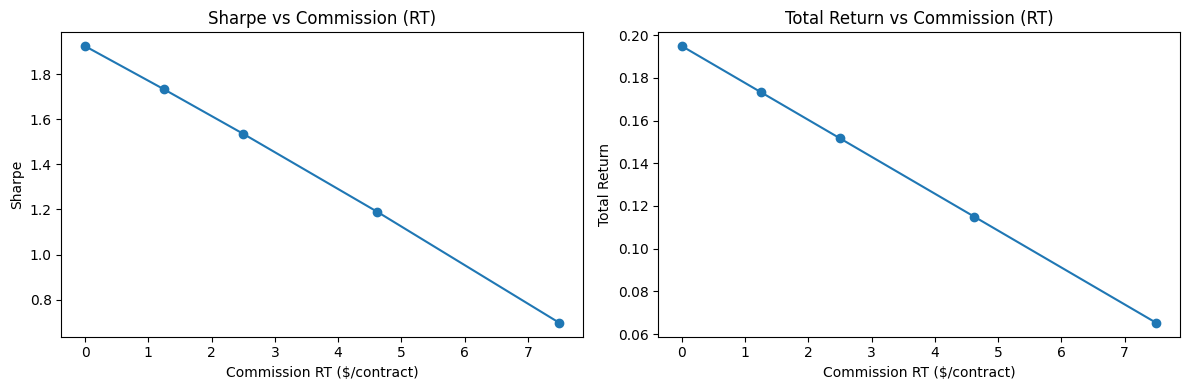

In [20]:
# RIGOR 10: Transaction-cost sensitivity (commission sweep)

commission_grid = [0.00, 1.25, 2.50, 4.62, 7.50]
cost_rows = []

base_frame = prices[["close"]].join(bot5_signals[["signal", "exit_signal", "exit_reason"]])
for c in commission_grid:
    bt_c = run_backtest(
        base_frame,
        commission_rt=float(c),
        slippage_ticks=1,
        tick_size=0.25,
    )
    cost_rows.append(
        {
            "commission_rt": float(c),
            "fee_per_side": float(c / 2.0),
            "total_return": bt_c["metrics"]["total_return"],
            "sharpe": bt_c["metrics"]["sharpe"],
            "total_trades": bt_c["metrics"]["total_trades"],
            "max_drawdown_dollars": bt_c["metrics"]["max_drawdown_dollars"],
        }
    )

cost_sensitivity_df = pd.DataFrame(cost_rows)
display(cost_sensitivity_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cost_sensitivity_df["commission_rt"], cost_sensitivity_df["sharpe"], marker="o")
axes[0].set_title("Sharpe vs Commission (RT)")
axes[0].set_xlabel("Commission RT ($/contract)")
axes[0].set_ylabel("Sharpe")

axes[1].plot(cost_sensitivity_df["commission_rt"], cost_sensitivity_df["total_return"], marker="o")
axes[1].set_title("Total Return vs Commission (RT)")
axes[1].set_xlabel("Commission RT ($/contract)")
axes[1].set_ylabel("Total Return")

plt.tight_layout()

In [21]:
# Optional exports for the new analysis sections
analysis_df.to_csv(OUT_DIR / "bot5_analysis_daily_returns.csv")
stability_df.to_csv(OUT_DIR / "bot5_parameter_stability.csv", index=False)
wf_df.to_csv(OUT_DIR / "bot5_walkforward_monthly.csv", index=False)
period_df.to_csv(OUT_DIR / "bot5_period_breakdown.csv", index=False)
rv_filter_df.to_csv(OUT_DIR / "bot5_regime_filter_sweep.csv", index=False)
forensics_df.to_csv(OUT_DIR / "bot5_aug_sep_drawdown_forensics.csv")
cost_sensitivity_df.to_csv(OUT_DIR / "bot5_cost_sensitivity.csv", index=False)

print("Saved:", OUT_DIR / "bot5_analysis_daily_returns.csv")
print("Saved:", OUT_DIR / "bot5_parameter_stability.csv")
print("Saved:", OUT_DIR / "bot5_walkforward_monthly.csv")
print("Saved:", OUT_DIR / "bot5_period_breakdown.csv")
print("Saved:", OUT_DIR / "bot5_regime_filter_sweep.csv")
print("Saved:", OUT_DIR / "bot5_aug_sep_drawdown_forensics.csv")
print("Saved:", OUT_DIR / "bot5_cost_sensitivity.csv")

Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_analysis_daily_returns.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_parameter_stability.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_walkforward_monthly.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_period_breakdown.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_regime_filter_sweep.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_aug_sep_drawdown_forensics.csv
Saved: /Users/user/Documents/GitHub/tradingalgoNotebook/outputs/bot5_cost_sensitivity.csv
